In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# [CELL 1]
import os

# Create target directory in Kaggle's persistent working folder
PROJECT_DIR = '/kaggle/working/processed_data'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory ready at: {PROJECT_DIR}")

# Install Copernicus API (Kaggle already has PyTorch, Xarray, Dask, etc.)

!pip install -q copernicusmarine netCDF4

import copernicusmarine
from kaggle_secrets import UserSecretsClient

# Secure login using Kaggle Secrets
try:
    user_secrets = UserSecretsClient()
    c_user = user_secrets.get_secret("COPERNICUS_USER")
    c_pass = user_secrets.get_secret("COPERNICUS_PASS")
    copernicusmarine.login(username=c_user, password=c_pass, force_overwrite=True)
    print("Copernicus Marine login successful.")
except Exception as e:
    print("Could not load Kaggle Secrets. Please configure them or use manual login.")
    # Fallback manual login:
    # copernicusmarine.login(username="YOUR_USERNAME", password="YOUR_PASSWORD", force_overwrite=True)

Project directory ready at: /kaggle/working/processed_data
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.3 MB/s eta 0:00:00


INFO - 2026-10-05T06:19:52Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


Copernicus Marine login successful.


In [3]:
'''# [CELL 2]
import xarray as xr
import numpy as np
import torch
import copernicusmarine

# Updated boundaries for the Tropical/Monsoon Indian Ocean
LAT_MIN, LAT_MAX = -15, 25
LON_MIN, LON_MAX = 50, 100
START_DATE, END_DATE = '2010-01-01', '2025-01-01'
PROJECT_DIR = '/kaggle/working/processed_data'

print("Lazily mapping datasets...")

# 1. SST Data
SST_URL = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg"
# FIX: Explicitly set the backend engine to 'netcdf4'
ds_sst = xr.open_dataset(SST_URL, engine='netcdf4')

sst_lazy = ds_sst.sst.sel(latitude=slice(LAT_MIN, LAT_MAX), 
                          longitude=slice(LON_MIN, LON_MAX), 
                          time=slice(START_DATE, END_DATE))

# 2. SLA Data (Current global 0.125-degree dataset)
ds_sla = copernicusmarine.open_dataset(dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D")
sla_lazy = ds_sla.sla.sel(latitude=slice(LAT_MIN, LAT_MAX), 
                          longitude=slice(LON_MIN, LON_MAX), 
                          time=slice(START_DATE, END_DATE))

# 3. Spatial Alignment
sla_aligned = sla_lazy.interp(latitude=sst_lazy.latitude, longitude=sst_lazy.longitude, method='nearest')

# 4. Fill Landmasses
sst_filled = sst_lazy.fillna(0.0)
sla_filled = sla_aligned.fillna(0.0)

print("Triggering .compute() to load subset into RAM... (This may take several minutes)")
sst_mem = sst_filled.compute()
sla_mem = sla_filled.compute()

# 5. Temporal Pairing (Predict t+5)
X_xr = sst_mem.isel(time=slice(0, -5))
Y_xr = sla_mem.isel(time=slice(5, None))
dates = X_xr.time.values 

# 6. Z-Score Normalization
X_mean, X_std = X_xr.mean().item(), X_xr.std().item()
Y_mean, Y_std = Y_xr.mean().item(), Y_xr.std().item()
X_norm = (X_xr - X_mean) / X_std
Y_norm = (Y_xr - Y_mean) / Y_std

# 7. Convert to Tensors
X_tensor = torch.tensor(X_norm.values, dtype=torch.float32).unsqueeze(1)
Y_tensor = torch.tensor(Y_norm.values, dtype=torch.float32).unsqueeze(1)

# Save to Kaggle /working/ directory
print("Saving processed tensors to Kaggle working directory...")
torch.save(X_tensor, f"{PROJECT_DIR}/X_sst.pt")
torch.save(Y_tensor, f"{PROJECT_DIR}/Y_sla_t5.pt")
np.save(f"{PROJECT_DIR}/dates.npy", dates)
np.save(f"{PROJECT_DIR}/norm_stats.npy", np.array([X_mean, X_std, Y_mean, Y_std]))
print(f"Data ready. X shape: {X_tensor.shape}, Y shape: {Y_tensor.shape}")'''

'# [CELL 2]\nimport xarray as xr\nimport numpy as np\nimport torch\nimport copernicusmarine\n\n# Updated boundaries for the Tropical/Monsoon Indian Ocean\nLAT_MIN, LAT_MAX = -15, 25\nLON_MIN, LON_MAX = 50, 100\nSTART_DATE, END_DATE = \'2010-01-01\', \'2025-01-01\'\nPROJECT_DIR = \'/kaggle/working/processed_data\'\n\nprint("Lazily mapping datasets...")\n\n# 1. SST Data\nSST_URL = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg"\n# FIX: Explicitly set the backend engine to \'netcdf4\'\nds_sst = xr.open_dataset(SST_URL, engine=\'netcdf4\')\n\nsst_lazy = ds_sst.sst.sel(latitude=slice(LAT_MIN, LAT_MAX), \n                          longitude=slice(LON_MIN, LON_MAX), \n                          time=slice(START_DATE, END_DATE))\n\n# 2. SLA Data (Current global 0.125-degree dataset)\nds_sla = copernicusmarine.open_dataset(dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D")\nsla_lazy = ds_sla.sla.sel(latitude=slice(LAT_MIN, LAT_MAX), \n                        

In [4]:
# [CELL 2]
import xarray as xr
import numpy as np
import torch
import copernicusmarine

# Updated boundaries and timeframe (2010-2025)
LAT_MIN, LAT_MAX = -15, 25
LON_MIN, LON_MAX = 50, 100
START_DATE, END_DATE = '2010-01-01', '2025-01-01'
PROJECT_DIR = '/kaggle/working/processed_data'

print("Lazily mapping datasets...")

# 1. SST Data (NOAA OISST)
SST_URL = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg"
ds_sst = xr.open_dataset(SST_URL, engine='netcdf4')

# Squeeze out the single 'zlev' depth dimension
sst_lazy = ds_sst.sst.sel(
    latitude=slice(LAT_MIN, LAT_MAX), 
    longitude=slice(LON_MIN, LON_MAX), 
    time=slice(START_DATE, END_DATE)
).squeeze(drop=True)

# 2. SLA Data (Copernicus)
ds_sla = copernicusmarine.open_dataset(dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D")
sla_lazy = ds_sla.sla.sel(
    latitude=slice(LAT_MIN, LAT_MAX), 
    longitude=slice(LON_MIN, LON_MAX), 
    time=slice(START_DATE, END_DATE)
).squeeze(drop=True)

# 3. Spatial and Temporal Alignment
# Interpolate SLA onto SST's exact latitude, longitude, AND time grids
sla_aligned = sla_lazy.interp(
    latitude=sst_lazy.latitude, 
    longitude=sst_lazy.longitude,
    time=sst_lazy.time,
    method='nearest'
)

# 4. Fill Landmasses
sst_filled = sst_lazy.fillna(0.0)
sla_filled = sla_aligned.fillna(0.0)

print("Triggering .compute() to load subset into RAM... (This may take several minutes)")
sst_mem = sst_filled.compute()
sla_mem = sla_filled.compute()

# 5. Temporal Pairing (Predict SLA at t+5)
X_xr = sst_mem.isel(time=slice(0, -5))
Y_xr = sla_mem.isel(time=slice(5, None))
dates = X_xr.time.values 

# 6. Z-Score Normalization
X_mean, X_std = X_xr.mean().item(), X_xr.std().item()
Y_mean, Y_std = Y_xr.mean().item(), Y_xr.std().item()
X_norm = (X_xr - X_mean) / X_std
Y_norm = (Y_xr - Y_mean) / Y_std

# 7. Convert to 4D Tensors: [Samples, 1, Height, Width]
X_tensor = torch.tensor(X_norm.values, dtype=torch.float32).unsqueeze(1)
Y_tensor = torch.tensor(Y_norm.values, dtype=torch.float32).unsqueeze(1)

print("Saving processed tensors to Kaggle working directory...")
torch.save(X_tensor, f"{PROJECT_DIR}/X_sst.pt")
torch.save(Y_tensor, f"{PROJECT_DIR}/Y_sla_t5.pt")
np.save(f"{PROJECT_DIR}/dates.npy", dates)
np.save(f"{PROJECT_DIR}/norm_stats.npy", np.array([X_mean, X_std, Y_mean, Y_std]))

print(f"Data ready. X shape: {X_tensor.shape}, Y shape: {Y_tensor.shape}")

Lazily mapping datasets...


INFO - 2026-10-05T06:20:05Z - Selected dataset version: "202411"
INFO - 2026-10-05T06:20:05Z - Selected dataset part: "default"


Triggering .compute() to load subset into RAM... (This may take several minutes)
Saving processed tensors to Kaggle working directory...
Data ready. X shape: torch.Size([5459, 1, 160, 200]), Y shape: torch.Size([5459, 1, 160, 200])


In [5]:
# [CELL 3]
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

PROJECT_DIR = '/kaggle/working/processed_data'

if 'dates' not in locals() or 'X_tensor' not in locals() or 'Y_tensor' not in locals():
    print("Variables not found in memory. Loading saved tensors from /kaggle/working/...")
    X_tensor = torch.load(f"{PROJECT_DIR}/X_sst.pt", weights_only=False)
    Y_tensor = torch.load(f"{PROJECT_DIR}/Y_sla_t5.pt", weights_only=False)
    dates = np.load(f"{PROJECT_DIR}/dates.npy", allow_pickle=True)

dates_pd = pd.to_datetime(dates)

train_mask = dates_pd.year <= 2020
test_mask = dates_pd.year >= 2021

X_train, Y_train = X_tensor[train_mask], Y_tensor[train_mask]
X_test, Y_test = X_tensor[test_mask], Y_tensor[test_mask]
test_dates = dates_pd[test_mask]

BATCH_SIZE = 16
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4018
Testing samples: 1441


In [6]:
'''# [CELL 4]
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class OceanUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(1, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(64, 32)
        self.outc = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        _, _, H, W = x.size()
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16
        x_pad = F.pad(x, (0, pad_w, 0, pad_h))
        
        x1 = self.inc(x_pad)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x = self.up1(x4)
        x = torch.cat([x2[:, :, :x.size(2), :x.size(3)] * 0 + x, x3], dim=1) 
        x = self.conv_up1(torch.cat([x, x3], dim=1))
        
        x = self.up2(x)
        x = self.conv_up2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv_up3(torch.cat([x, x1], dim=1))
        
        logits = self.outc(x)
        return logits[:, :, :H, :W]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = OceanUNet().to(device)
print(f"Model initialized on {device}.")'''

'# [CELL 4]\nimport torch.nn as nn\nimport torch.nn.functional as F\n\nclass DoubleConv(nn.Module):\n    def __init__(self, in_channels, out_channels):\n        super().__init__()\n        self.conv = nn.Sequential(\n            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),\n            nn.BatchNorm2d(out_channels),\n            nn.SiLU(inplace=True),\n            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),\n            nn.BatchNorm2d(out_channels),\n            nn.SiLU(inplace=True)\n        )\n    def forward(self, x): return self.conv(x)\n\nclass OceanUNet(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.inc = DoubleConv(1, 32)\n        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))\n        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))\n        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))\n        \n        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size

In [7]:
# [CELL 4]
import torch.nn as nn
import torch.nn.functional as F
import torch

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )
    def forward(self, x): 
        return self.conv(x)

class OceanUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.inc = DoubleConv(1, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        
        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)
        
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(64, 32)
        
        # Output
        self.outc = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        _, _, H, W = x.size()
        
        # 1. Pad spatial dimensions to a multiple of 16 to ensure perfect pooling/upsampling
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16
        x = F.pad(x, (0, pad_w, 0, pad_h))
        
        # 2. Downsample (Encoder)
        x1 = self.inc(x)       # Channels: 32
        x2 = self.down1(x1)    # Channels: 64
        x3 = self.down2(x2)    # Channels: 128
        x4 = self.down3(x3)    # Channels: 256
        
        # 3. Upsample (Decoder) + Skip Connections
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)  # 128 + 128 = 256
        x = self.conv_up1(x)           # 256 -> 128
        
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)  # 64 + 64 = 128
        x = self.conv_up2(x)           # 128 -> 64
        
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)  # 32 + 32 = 64
        x = self.conv_up3(x)           # 64 -> 32
        
        # 4. Final Convolution
        logits = self.outc(x)
        
        # 5. Crop back to the original input dimensions to remove padding
        return logits[:, :, :H, :W]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = OceanUNet().to(device)
print(f"Model initialized on {device}.")

Model initialized on cuda.


In [8]:
# [CELL 5]
import torch.optim as optim

EPOCHS = 30
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_loss = float('inf')
MODEL_PATH = f"{PROJECT_DIR}/unet_sst_sla_best.pth"

print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for batch_X, batch_Y in train_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)
        
    train_loss /= len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f}")
    
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"--> Saved best model")

Starting training...
Epoch [1/30] | Train Loss: 0.7963
--> Saved best model
Epoch [2/30] | Train Loss: 0.6598
--> Saved best model
Epoch [3/30] | Train Loss: 0.5504
--> Saved best model
Epoch [4/30] | Train Loss: 0.4841
--> Saved best model
Epoch [5/30] | Train Loss: 0.4341
--> Saved best model
Epoch [6/30] | Train Loss: 0.3927
--> Saved best model
Epoch [7/30] | Train Loss: 0.3652
--> Saved best model
Epoch [8/30] | Train Loss: 0.3336
--> Saved best model
Epoch [9/30] | Train Loss: 0.3013
--> Saved best model
Epoch [10/30] | Train Loss: 0.2753
--> Saved best model
Epoch [11/30] | Train Loss: 0.2592
--> Saved best model
Epoch [12/30] | Train Loss: 0.2386
--> Saved best model
Epoch [13/30] | Train Loss: 0.2206
--> Saved best model
Epoch [14/30] | Train Loss: 0.1968
--> Saved best model
Epoch [15/30] | Train Loss: 0.1828
--> Saved best model
Epoch [16/30] | Train Loss: 0.1709
--> Saved best model
Epoch [17/30] | Train Loss: 0.1572
--> Saved best model
Epoch [18/30] | Train Loss: 0.1458
-

In [9]:
'''# [CELL 6]
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

all_preds, all_gts = [], []

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        outputs = model(batch_X.to(device))
        all_preds.append(outputs.cpu().numpy())
        all_gts.append(batch_Y.numpy())

preds = np.concatenate(all_preds, axis=0).squeeze()
gts = np.concatenate(all_gts, axis=0).squeeze()

months = test_dates.month
mask_sw = np.isin(months, [6, 7, 8, 9])
mask_ne = np.isin(months, [12, 1, 2, 3])
mask_inter = np.isin(months, [4, 5, 10, 11])

def calc_metrics(pred_arr, gt_arr):
    if len(gt_arr) == 0: return 0.0, 0.0
    rmse = np.sqrt(np.mean((pred_arr - gt_arr)**2))
    ssims = [ssim(g, p, data_range=gt_arr.max()-gt_arr.min()) for p, g in zip(pred_arr, gt_arr)]
    return rmse, np.mean(ssims)

rmse_sw, ssim_sw = calc_metrics(preds[mask_sw], gts[mask_sw])
rmse_ne, ssim_ne = calc_metrics(preds[mask_ne], gts[mask_ne])
rmse_in, ssim_in = calc_metrics(preds[mask_inter], gts[mask_inter])

print("=== Monsoon Phase Specific Evaluation (2021-2025) ===")
print(f"SW Monsoon (Jun-Sep): RMSE = {rmse_sw:.4f} | SSIM = {ssim_sw:.4f}")
print(f"NE Monsoon (Dec-Mar): RMSE = {rmse_ne:.4f} | SSIM = {ssim_ne:.4f}")
print(f"Inter-Monsoon       : RMSE = {rmse_in:.4f} | SSIM = {ssim_in:.4f}")

def plot_pred(idx, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    gt, pr = gts[idx], preds[idx]
    
    im0 = axes[0].imshow(gt, cmap='coolwarm', origin='lower')
    axes[0].set_title(f"GT SLA\n{test_dates.iloc[idx].date()}")
    fig.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(pr, cmap='coolwarm', origin='lower')
    axes[1].set_title("Predicted SLA")
    fig.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(pr - gt, cmap='RdBu_r', origin='lower')
    axes[2].set_title("Error Map (Pred - GT)")
    fig.colorbar(im2, ax=axes[2])
    
    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

if mask_sw.any(): plot_pred(np.where(mask_sw)[0][0], "Southwest Monsoon Sample")
if mask_ne.any(): plot_pred(np.where(mask_ne)[0][0], "Northeast Monsoon Sample")'''

'# [CELL 6]\nimport matplotlib.pyplot as plt\nfrom skimage.metrics import structural_similarity as ssim\n\nmodel.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))\nmodel.eval()\n\nall_preds, all_gts = [], []\n\nwith torch.no_grad():\n    for batch_X, batch_Y in test_loader:\n        outputs = model(batch_X.to(device))\n        all_preds.append(outputs.cpu().numpy())\n        all_gts.append(batch_Y.numpy())\n\npreds = np.concatenate(all_preds, axis=0).squeeze()\ngts = np.concatenate(all_gts, axis=0).squeeze()\n\nmonths = test_dates.month\nmask_sw = np.isin(months, [6, 7, 8, 9])\nmask_ne = np.isin(months, [12, 1, 2, 3])\nmask_inter = np.isin(months, [4, 5, 10, 11])\n\ndef calc_metrics(pred_arr, gt_arr):\n    if len(gt_arr) == 0: return 0.0, 0.0\n    rmse = np.sqrt(np.mean((pred_arr - gt_arr)**2))\n    ssims = [ssim(g, p, data_range=gt_arr.max()-gt_arr.min()) for p, g in zip(pred_arr, gt_arr)]\n    return rmse, np.mean(ssims)\n\nrmse_sw, ssim_sw = calc_metric

=== Monsoon Phase Specific Evaluation (2021-2025) ===
SW Monsoon (Jun-Sep): RMSE = 0.8138 | SSIM = 0.3592
NE Monsoon (Dec-Mar): RMSE = 0.8963 | SSIM = 0.3486
Inter-Monsoon       : RMSE = 0.9416 | SSIM = 0.3722


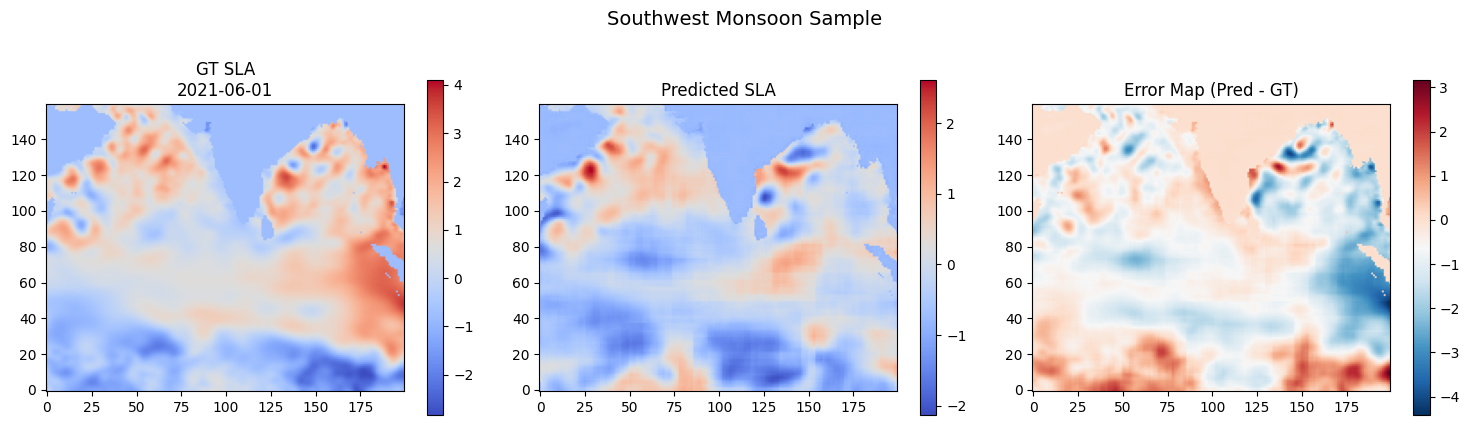

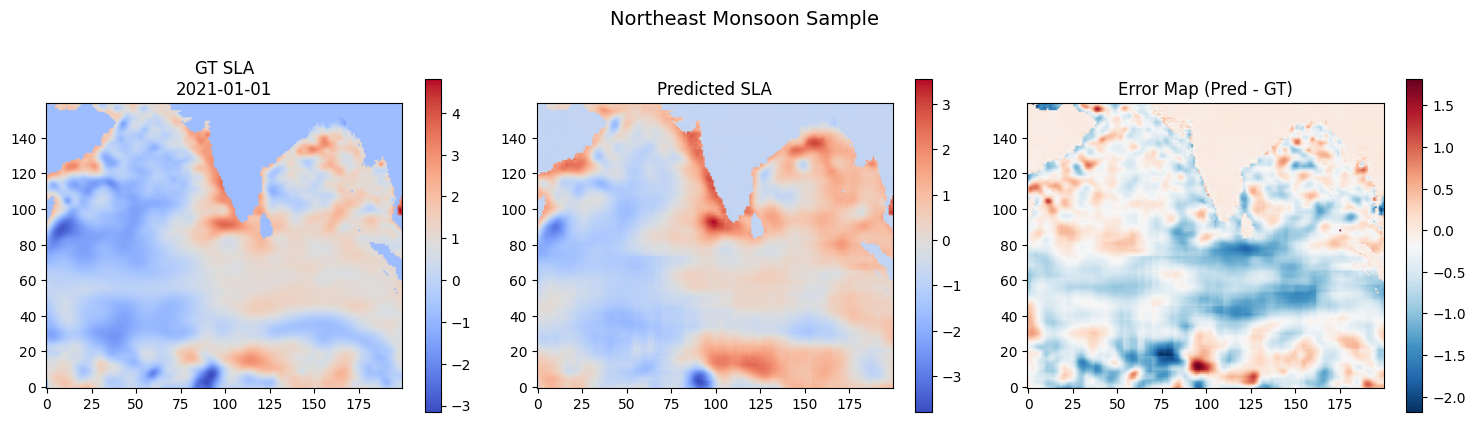

In [10]:
# [CELL 6]
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import numpy as np
import torch

# Load best weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

all_preds, all_gts = [], []

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        outputs = model(batch_X.to(device))
        all_preds.append(outputs.cpu().numpy())
        all_gts.append(batch_Y.numpy())

preds = np.concatenate(all_preds, axis=0).squeeze()
gts = np.concatenate(all_gts, axis=0).squeeze()

months = test_dates.month
mask_sw = np.isin(months, [6, 7, 8, 9])
mask_ne = np.isin(months, [12, 1, 2, 3])
mask_inter = np.isin(months, [4, 5, 10, 11])

def calc_metrics(pred_arr, gt_arr):
    if len(gt_arr) == 0: return 0.0, 0.0
    rmse = np.sqrt(np.mean((pred_arr - gt_arr)**2))
    ssims = [ssim(g, p, data_range=gt_arr.max()-gt_arr.min()) for p, g in zip(pred_arr, gt_arr)]
    return rmse, np.mean(ssims)

rmse_sw, ssim_sw = calc_metrics(preds[mask_sw], gts[mask_sw])
rmse_ne, ssim_ne = calc_metrics(preds[mask_ne], gts[mask_ne])
rmse_in, ssim_in = calc_metrics(preds[mask_inter], gts[mask_inter])

print("=== Monsoon Phase Specific Evaluation (2021-2025) ===")
print(f"SW Monsoon (Jun-Sep): RMSE = {rmse_sw:.4f} | SSIM = {ssim_sw:.4f}")
print(f"NE Monsoon (Dec-Mar): RMSE = {rmse_ne:.4f} | SSIM = {ssim_ne:.4f}")
print(f"Inter-Monsoon       : RMSE = {rmse_in:.4f} | SSIM = {ssim_in:.4f}")

def plot_pred(idx, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    gt, pr = gts[idx], preds[idx]
    
    im0 = axes[0].imshow(gt, cmap='coolwarm', origin='lower')
    # FIX: DatetimeIndex is accessed directly, not via .iloc
    axes[0].set_title(f"GT SLA\n{test_dates[idx].date()}")
    fig.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(pr, cmap='coolwarm', origin='lower')
    axes[1].set_title("Predicted SLA")
    fig.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(pr - gt, cmap='RdBu_r', origin='lower')
    axes[2].set_title("Error Map (Pred - GT)")
    fig.colorbar(im2, ax=axes[2])
    
    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

if mask_sw.any(): plot_pred(np.where(mask_sw)[0][0], "Southwest Monsoon Sample")
if mask_ne.any(): plot_pred(np.where(mask_ne)[0][0], "Northeast Monsoon Sample")

=== Monsoon Phase Specific Evaluation (2021-2025) ===
SW Monsoon (Jun-Sep): RMSE = 0.8138 | SSIM = 0.3592
NE Monsoon (Dec-Mar): RMSE = 0.8963 | SSIM = 0.3486
Inter-Monsoon       : RMSE = 0.9416 | SSIM = 0.3722
--------------------------------------------------


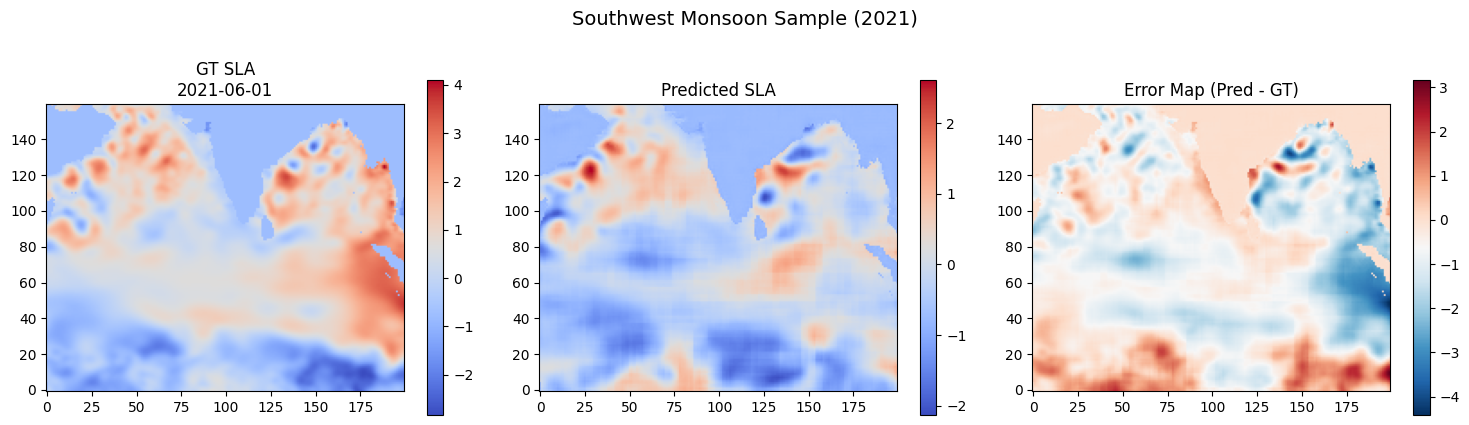

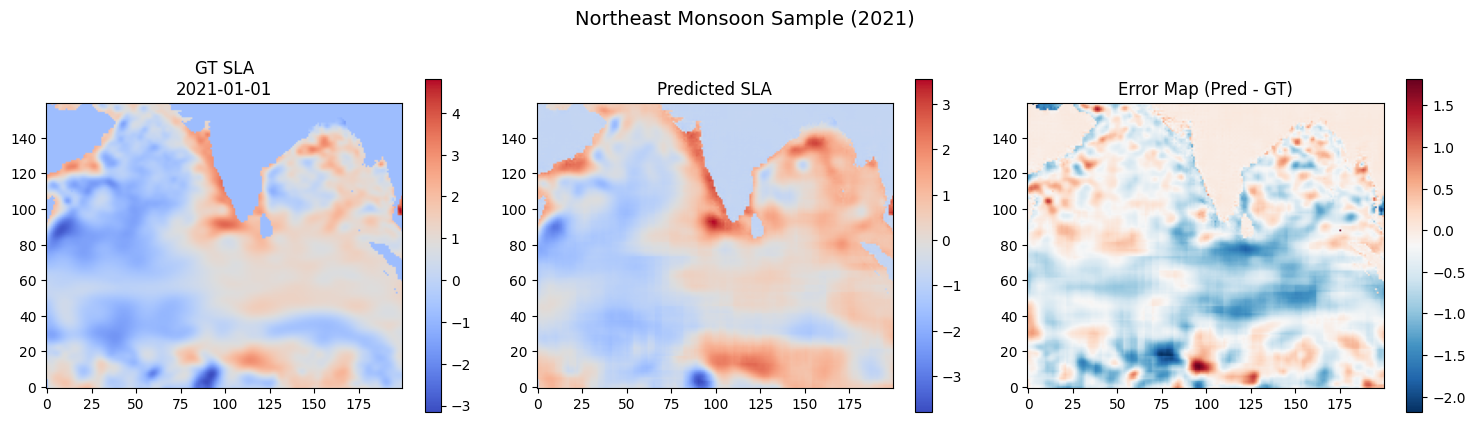

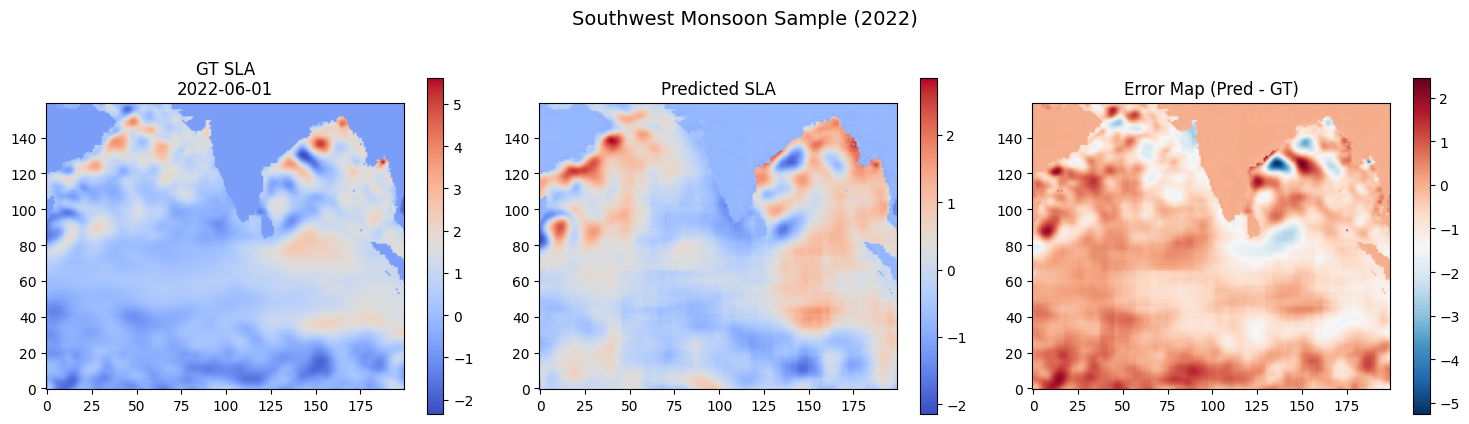

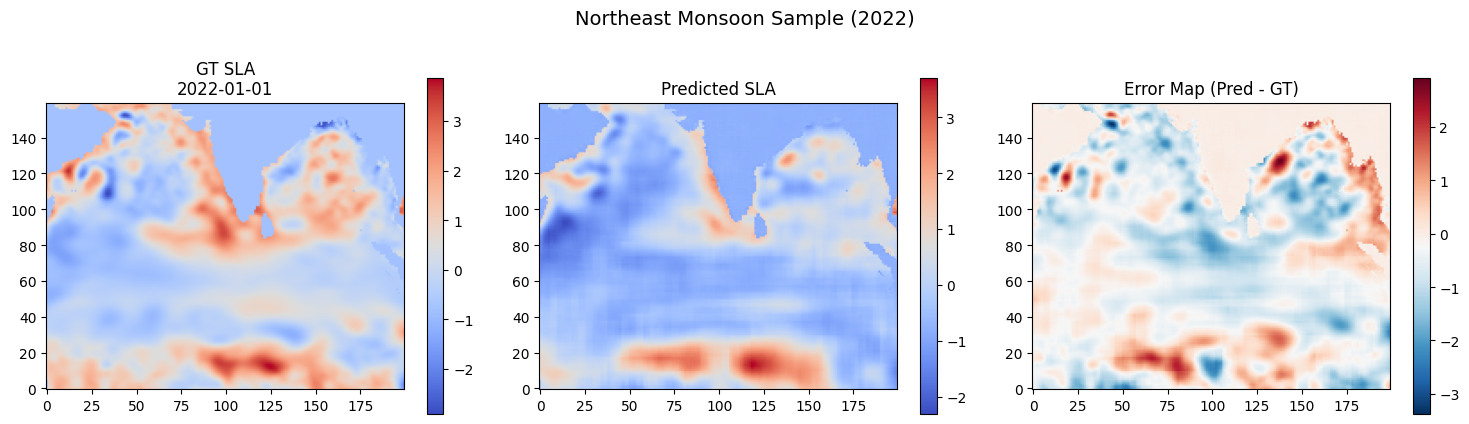

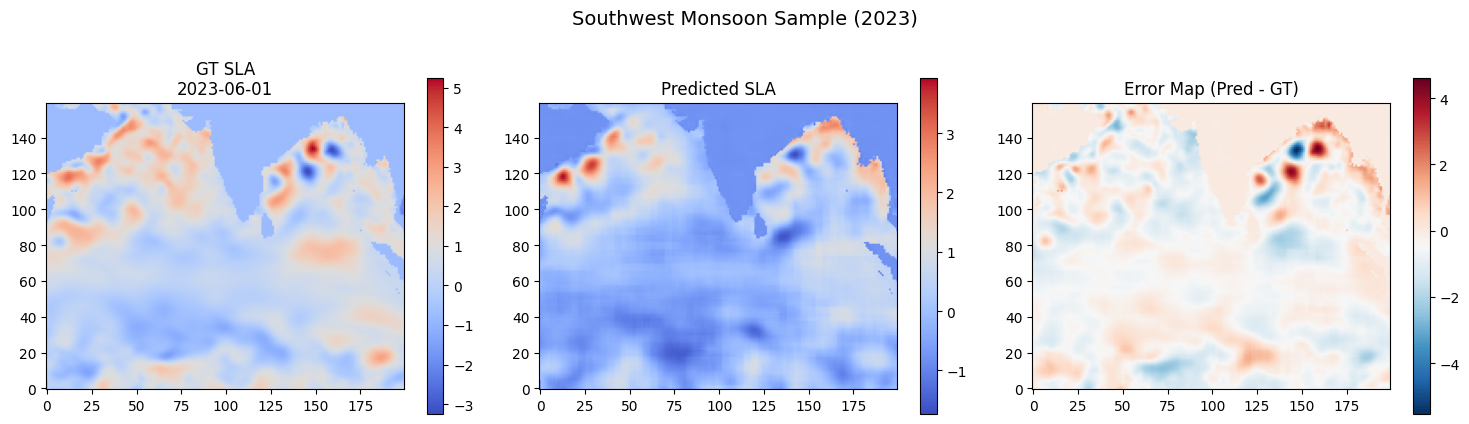

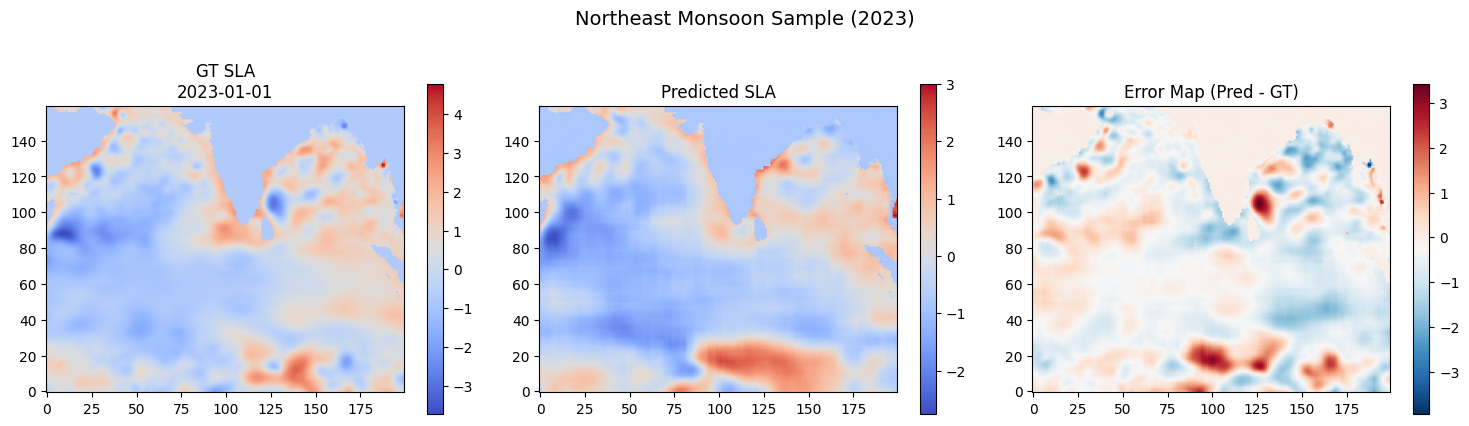

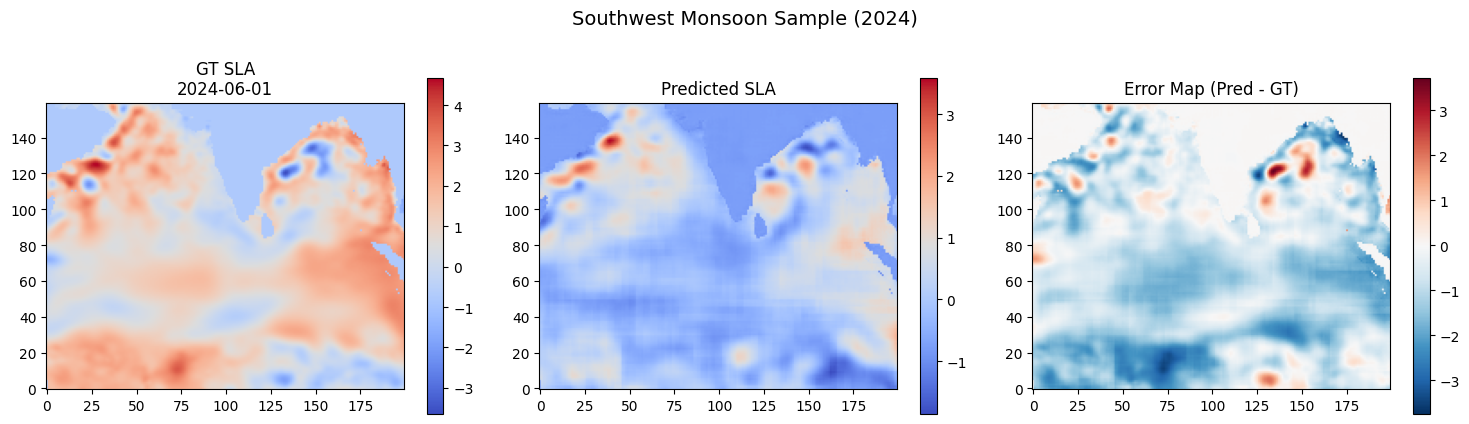

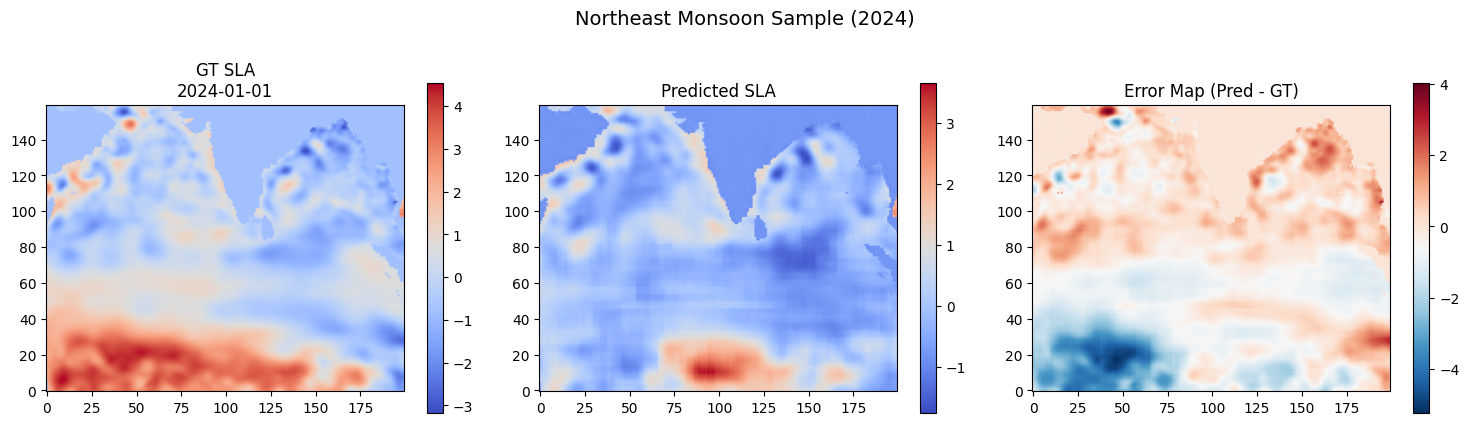

In [11]:
# [CELL 6]
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import numpy as np
import torch

# Load best weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

all_preds, all_gts = [], []

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        outputs = model(batch_X.to(device))
        all_preds.append(outputs.cpu().numpy())
        all_gts.append(batch_Y.numpy())

preds = np.concatenate(all_preds, axis=0).squeeze()
gts = np.concatenate(all_gts, axis=0).squeeze()

months = test_dates.month
mask_sw = np.isin(months, [6, 7, 8, 9])
mask_ne = np.isin(months, [12, 1, 2, 3])
mask_inter = np.isin(months, [4, 5, 10, 11])

def calc_metrics(pred_arr, gt_arr):
    if len(gt_arr) == 0: return 0.0, 0.0
    rmse = np.sqrt(np.mean((pred_arr - gt_arr)**2))
    ssims = [ssim(g, p, data_range=gt_arr.max()-gt_arr.min()) for p, g in zip(pred_arr, gt_arr)]
    return rmse, np.mean(ssims)

rmse_sw, ssim_sw = calc_metrics(preds[mask_sw], gts[mask_sw])
rmse_ne, ssim_ne = calc_metrics(preds[mask_ne], gts[mask_ne])
rmse_in, ssim_in = calc_metrics(preds[mask_inter], gts[mask_inter])

print("=== Monsoon Phase Specific Evaluation (2021-2025) ===")
print(f"SW Monsoon (Jun-Sep): RMSE = {rmse_sw:.4f} | SSIM = {ssim_sw:.4f}")
print(f"NE Monsoon (Dec-Mar): RMSE = {rmse_ne:.4f} | SSIM = {ssim_ne:.4f}")
print(f"Inter-Monsoon       : RMSE = {rmse_in:.4f} | SSIM = {ssim_in:.4f}")
print("-" * 50)

def plot_pred(idx, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    gt, pr = gts[idx], preds[idx]
    
    im0 = axes[0].imshow(gt, cmap='coolwarm', origin='lower')
    axes[0].set_title(f"GT SLA\n{test_dates[idx].date()}")
    fig.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(pr, cmap='coolwarm', origin='lower')
    axes[1].set_title("Predicted SLA")
    fig.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(pr - gt, cmap='RdBu_r', origin='lower')
    axes[2].set_title("Error Map (Pred - GT)")
    fig.colorbar(im2, ax=axes[2])
    
    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

# NEW LOGIC: Loop through each unique year and plot one SW and one NE sample
unique_years = test_dates.year.unique()

for year in unique_years:
    # Create a mask for just this specific year
    mask_year = test_dates.year == year
    
    # Find the intersection of the year mask and the monsoon masks
    year_sw_mask = mask_sw & mask_year
    year_ne_mask = mask_ne & mask_year
    
    # If there are Southwest monsoon days in this year, plot the first one
    if year_sw_mask.any():
        idx_sw = np.where(year_sw_mask)[0][0]
        plot_pred(idx_sw, f"Southwest Monsoon Sample ({year})")
        
    # If there are Northeast monsoon days in this year, plot the first one
    if year_ne_mask.any():
        idx_ne = np.where(year_ne_mask)[0][0]
        plot_pred(idx_ne, f"Northeast Monsoon Sample ({year})")